## Regression

- Diabetes(당뇨병) 데이터 사용

### Import Libraries

In [180]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
# 당뇨병 데이터 사용 (Kaggle)
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


### Load and Explore Data

In [181]:
# Load Diabetes dataset
data = load_diabetes()

# Extract features and target
X = data.data
y = data.target

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names: {data.feature_names}")
print(f"Target: Diabetes progression (quantitative measure of disease progression one year after baseline)")

# Display statistics
print(f"\nTarget statistics:")
print(f"  Min: {y.min():.2f}")
print(f"  Max: {y.max():.2f}")
print(f"  Mean: {y.mean():.2f}")

Dataset Information:
Number of samples: 442
Number of features: 10

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target: Diabetes progression (quantitative measure of disease progression one year after baseline)

Target statistics:
  Min: 25.00
  Max: 346.00
  Mean: 152.13


### Data Preprocessing

In [182]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Normalize features using StandardScaler
# This helps neural networks train faster and more stably
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data normalized (mean=0, std=1)")

Training set size: 353 samples
Test set size: 89 samples

✓ Data normalized (mean=0, std=1)


### Convert to PyTorch Tensors

In [212]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for batch processing
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 16
Number of training batches: 23
Number of test batches: 6


### Model Definition

In [213]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(RegressionModel, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 1)  # Output layer

    def forward(self, x):
        # Forward pass through the network
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Initialize model
input_size = X_train_scaled.shape[1]  # Number of features (10)
model = RegressionModel(input_size).to(device)

print(model)
print(f"\nModel moved to: {device}")

RegressionModel(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Model moved to: cuda


### Loss Function and Optimizer

In [214]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam with learning rate 0.001
learning_rate = 0.003
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.003


### Training Loop

In [215]:
# Training parameters
num_epochs = 300

# Track losses for visualization
train_losses = []
test_losses = []

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move data to device (GPU if available)
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. Forward pass: compute predictions
        predictions = model(X_batch)

        # 2. Compute loss
        loss = criterion(predictions, y_batch)

        # 3. Backward pass: compute gradients
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Compute new gradients

        # 4. Update weights
        optimizer.step()

        train_loss += loss.item()

    # Average training loss for this epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation phase (no gradient computation needed)
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

print("-" * 60)
print("Training complete!")

Starting training...
------------------------------------------------------------
Epoch [10/300] | Train Loss: 7670.2577 | Test Loss: 5954.2707
Epoch [20/300] | Train Loss: 3849.3096 | Test Loss: 3565.5574
Epoch [30/300] | Train Loss: 2985.4477 | Test Loss: 3105.3295
Epoch [40/300] | Train Loss: 2946.5550 | Test Loss: 2897.8824
Epoch [50/300] | Train Loss: 2859.8096 | Test Loss: 2775.9792
Epoch [60/300] | Train Loss: 2646.0426 | Test Loss: 2719.9088
Epoch [70/300] | Train Loss: 2591.0327 | Test Loss: 2679.4305
Epoch [80/300] | Train Loss: 2587.1257 | Test Loss: 2656.1813
Epoch [90/300] | Train Loss: 2546.4318 | Test Loss: 2643.0424
Epoch [100/300] | Train Loss: 2565.5707 | Test Loss: 2689.9655
Epoch [110/300] | Train Loss: 2481.0317 | Test Loss: 2587.2272
Epoch [120/300] | Train Loss: 2475.3050 | Test Loss: 2566.8514
Epoch [130/300] | Train Loss: 2794.9970 | Test Loss: 2545.0857
Epoch [140/300] | Train Loss: 2472.8076 | Test Loss: 2555.2827
Epoch [150/300] | Train Loss: 2906.4448 | Tes

### Visualize Training Progress

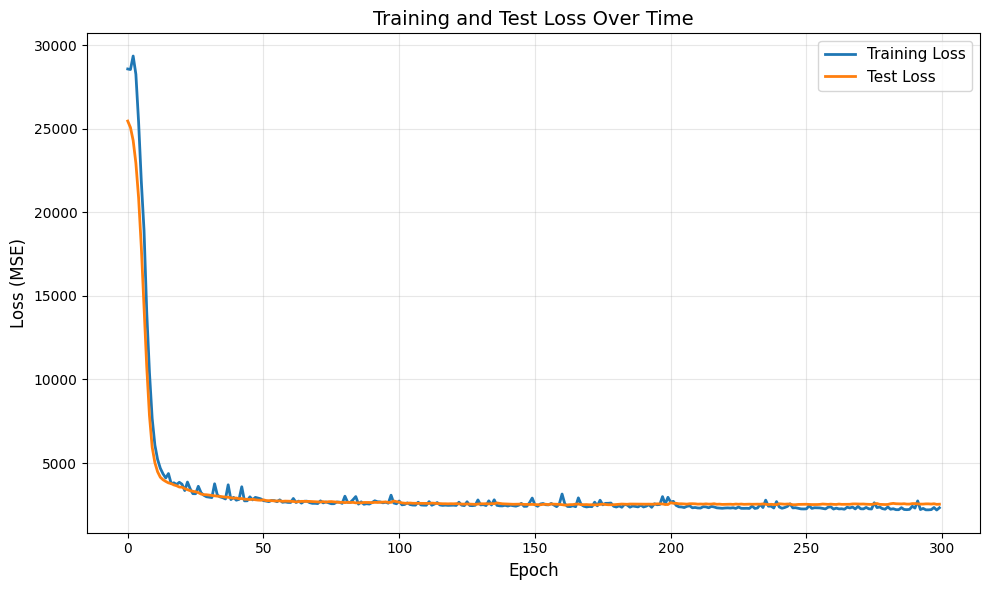

Final Training Loss: 2325.4142
Final Test Loss: 2538.9167


In [216]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Test Loss Over Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

### Model Evaluation

In [217]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred = model(X_test_device).cpu().numpy()
    y_true = y_test_tensor.numpy()

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print("Model Performance on Test Set:")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print("=" * 50)
print(f"\nInterpretation:")
print(f"On average, predictions are off by {mae:.2f} units")
print(f"Model explains {r2*100:.2f}% of the variance in diabetes progression")

Model Performance on Test Set:
Mean Squared Error (MSE):  2594.6799
Root Mean Squared Error (RMSE): 50.9380
Mean Absolute Error (MAE): 40.5110
R² Score: 0.5103

Interpretation:
On average, predictions are off by 40.51 units
Model explains 51.03% of the variance in diabetes progression


### Visualize Predictions

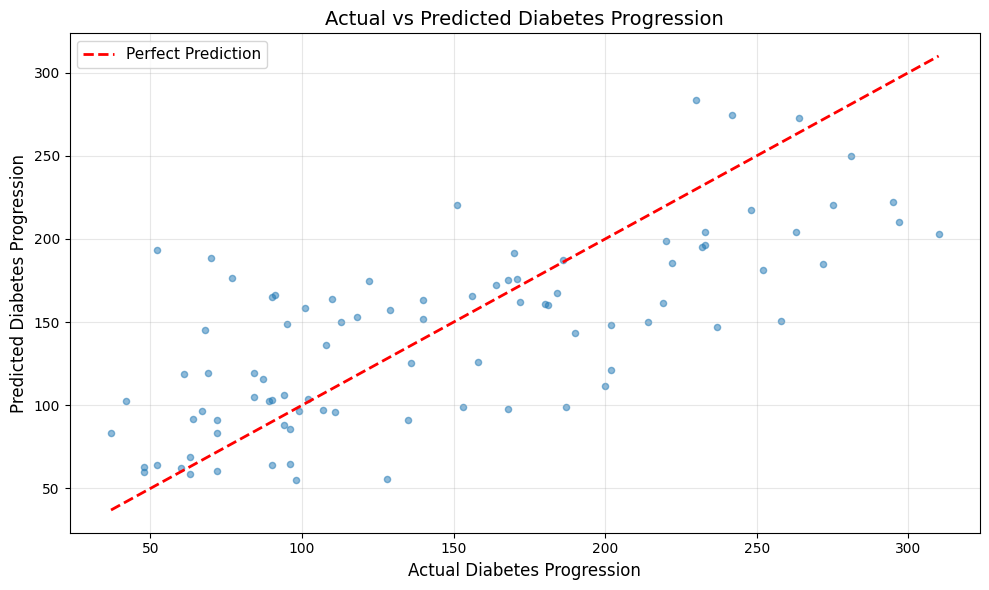


Sample Predictions (first 10 samples):
------------------------------------------------------------
      Actual |    Predicted |   Difference
------------------------------------------------------------
      219.00 |       161.46 |        57.54
       70.00 |       188.33 |      -118.33
      202.00 |       148.36 |        53.64
      230.00 |       283.28 |       -53.28
      111.00 |        96.24 |        14.76
       84.00 |       119.17 |       -35.17
      242.00 |       274.82 |       -32.82
      272.00 |       184.88 |        87.12
       94.00 |        88.39 |         5.61
       96.00 |        85.68 |        10.32


In [218]:
# Create scatter plot of predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Diabetes Progression', fontsize=12)
plt.ylabel('Predicted Diabetes Progression', fontsize=12)
plt.title('Actual vs Predicted Diabetes Progression', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 samples):")
print("-" * 60)
print(f"{'Actual':>12} | {'Predicted':>12} | {'Difference':>12}")
print("-" * 60)
for i in range(min(10, len(y_true))):
    actual = y_true[i][0]
    predicted = y_pred[i][0]
    diff = actual - predicted
    print(f"{actual:>12.2f} | {predicted:>12.2f} | {diff:>12.2f}")

### Save the Model (Optional)

In [219]:
# Save model
torch.save(model.state_dict(), 'diabetes_model.pth')
print("✓ Model saved to 'diabetes_model.pth'")

# To load the model later:
# model = RegressionModel(input_size)
# model.load_state_dict(torch.load('diabetes_model.pth'))
# model.to(device)
# model.eval()

print("\nTo load this model later, use:")
print("  model = RegressionModel(input_size)")
print("  model.load_state_dict(torch.load('diabetes_model.pth'))")
print("  model.to(device)")
print("  model.eval()")

✓ Model saved to 'diabetes_model.pth'

To load this model later, use:
  model = RegressionModel(input_size)
  model.load_state_dict(torch.load('diabetes_model.pth'))
  model.to(device)
  model.eval()
